WEEK 01 OF DIGITAL SIGNAL PROCESSING

In [2]:
import numpy as np
import matplotlib.pyplot as plt

GENERATING SINE WAVE

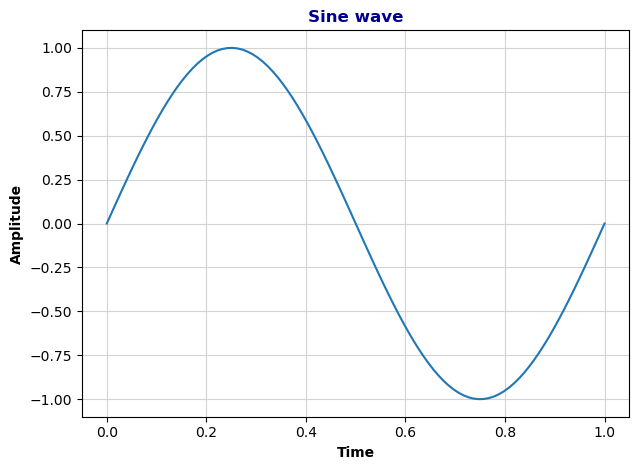

In [6]:
f=100       #sampling
t=1         #duration
x=np.linspace(0,t,f)    #x-axis (time)
y=np.sin(2*np.pi*x)     #y-axis (amplitude)
plt.Figure(figsize=(10,4))
plt.xlabel("Time",color="black",weight="bold")
plt.ylabel("Amplitude",color="black",weight="bold")
plt.title("Sine wave",weight="bold",color="darkblue")    #TITLE
plt.grid(True,color="lightgrey")
plt.tight_layout()
plt.plot(x,y)           #PLOTING
plt.show() 


SINE WAVE FOR DIFFERENT FREQUENCY 

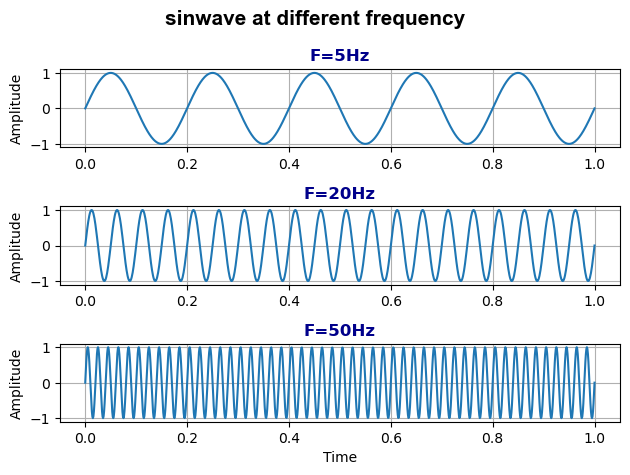

In [33]:
fig,axes=plt.subplots(3,1)   #creating subplots for different frequency
x=np.linspace(0,1,1000)
for i , fr in enumerate([5,20,50]):         #enumerate-> to access both index and value
    y=np.sin(2*np.pi*fr*x)
    axes[i].set_title(f"F={fr}Hz",color="darkblue",weight="bold")
    axes[i].grid(True)
    if i==2:
        axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Amplitude")
    axes[i].plot(x,y)
plt.suptitle("sinwave at different frequency",fontsize=15,font="Arial",weight="bold")  #main heading
plt.tight_layout()
plt.show()


When frequency increases, the number of cycles per second increases,
so the wave appears more compressed in the time plot.

When sampling rate drops from 1000 to 100, time resolution decreases —
fewer discrete points capture the wave, so the shape becomes less accurate.
This is because each sample now covers a larger time gap (0.01s vs 0.001s)

## Sampling Theorem & Aliasing
Nyquist theorem: to correctly represent a signal of frequency f,
you must sample at fs >= 2f.
What happens when you violate this?

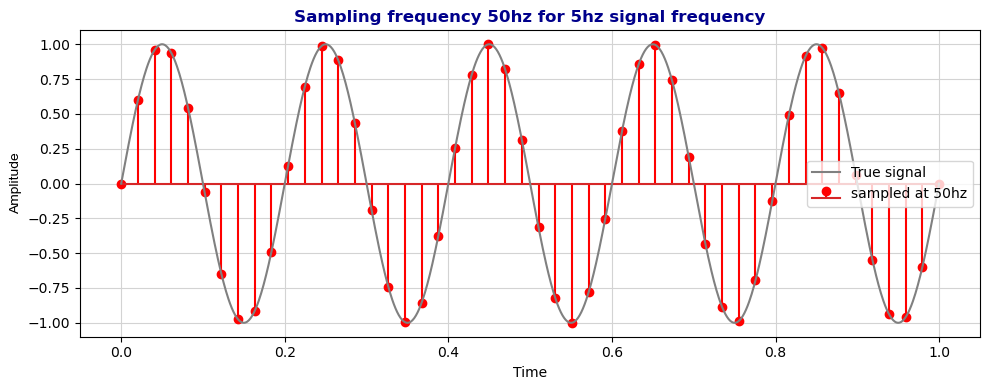

In [61]:
fs=5           # Signal frequency 5Hz
fm=50          # Sampling frequency >= signal frequency 
t=np.linspace(0,1,fm)       # x-axis 
y=np.sin(2*np.pi*t*fs)      #y-axis

# True signal for comparision 
t1=np.linspace(0,1,1000)
y1=np.sin(2*np.pi*t1*fs)

#ploting
plt.figure(figsize=(10,4))
plt.stem(t,y,markerfmt="ro",linefmt="r",label=f"sampled at {fm}hz")       #ploting sampling frequency wave
plt.plot(t1,y1,color="grey",label="True signal")     #ploting true frequency wave
plt.xlabel("Time")
plt.ylabel("Amplitude",fontname='Arial')
plt.title(f"Sampling frequency {fm}hz for {fs}hz signal frequency",weight="bold",color="darkblue")
plt.tight_layout()
plt.legend()
plt.grid(True,color="lightgrey")
plt.show()


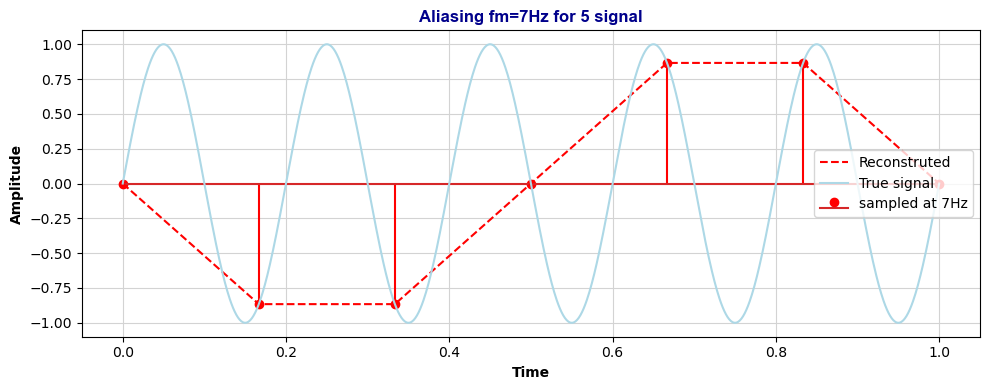

In [60]:
fs=5    # Signal frequency
fm=7    #sampling frequency - below Nyquist (at least 10 Hz for 5 Hz signal)
t=np.linspace(0,1,fm)
y=np.sin(2*np.pi*fs*t)
plt.figure(figsize=(10,4))
plt.stem(t,y,"ro",label=f"sampled at {fm}Hz")        # ploting discrete sampled values
plt.plot(t,y,"r--",label="Reconstruted")                                  # Joining plot points 
plt.plot(t1,y1,color="lightblue",label="True signal")     # true signal for comparision
plt.xlabel("Time",weight="bold")
plt.ylabel("Amplitude",weight="bold")
plt.title(f"Aliasing fm={fm}Hz for {fs} signal",weight="bold",fontname="Arial",color="darkblue")
plt.grid(True,color="lightgrey")
plt.tight_layout()
plt.legend()
plt.show()

ECG contains frequencies up to 150 Hz that means you need fs >= 300 Hz minimum .

Most modern ECG machines use 500 Hz or 1000 Hz for safety margin


## Aliasing Observation

A 5 Hz signal sampled at 8 Hz is undersampled (violates Nyquist — need at least 10 Hz).

The sampler cannot distinguish between 5 Hz and 3 Hz at this rate,
so the reconstructed signal appears as a fake 3 Hz wave.

Alias frequency = |fs - f_signal| = |8 - 5| = 3 Hz

This is dangerous in ECG because aliased high-frequency QRS components
could appear as low-frequency artifacts, making a normal heartbeat
look abnormal to a diagnostic algorithm.